In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
df= pd.read_csv("insurance.csv")

In [3]:
df.head()

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
0,1,39.0,male,23.2,91,Yes,0,No,southeast,1121.87
1,2,24.0,male,30.1,87,No,0,No,southeast,1131.51
2,3,NaN,male,33.3,82,Yes,0,No,southeast,1135.94
3,4,NaN,male,33.7,80,No,0,No,northwest,1136.40
4,5,NaN,male,34.1,100,No,0,No,northwest,1137.01


In [4]:
df.describe()

,Id,age,bmi,bloodpressure,children,claim
count,1340.000000,1335.000000,1340.000000,1340.000000,1340.000000,1340.000000
mean,670.500000,38.078652,30.668955,94.157463,1.093284,13252.745642
std,386.968991,11.102924,6.106735,11.434712,1.205334,12109.609288
min,1.000000,18.000000,16.000000,80.000000,0.000000,1121.870000
25%,335.750000,29.000000,26.275000,86.000000,0.000000,4719.685000
50%,670.500000,38.000000,30.400000,92.000000,1.000000,9369.615000
75%,1005.250000,47.000000,34.700000,99.000000,2.000000,16604.305000
max,1340.000000,60.000000,53.100000,140.000000,5.000000,63770.430000


In [5]:
df.isnull().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [6]:
df.isna().sum()

Id               0
age              5
gender           0
bmi              0
bloodpressure    0
diabetic         0
children         0
smoker           0
region           3
claim            0
dtype: int64

In [7]:
df.dropna(inplace=True)

In [8]:
df.shape

(1332, 10)

In [9]:
df.describe(include="all")

,Id,age,gender,bmi,bloodpressure,diabetic,children,smoker,region,claim
count,1332.000000,1332.000000,1332,1332.000000,1332.000000,1332,1332.000000,1332,1332,1332.000000
unique,NaN,NaN,2,NaN,NaN,2,NaN,2,4,NaN
top,NaN,NaN,male,NaN,NaN,No,NaN,No,southeast,NaN
freq,NaN,NaN,670,NaN,NaN,695,NaN,1058,442,NaN
mean,674.474474,38.086336,NaN,30.658333,94.189189,NaN,1.099850,NaN,NaN,13325.246426
std,384.703785,11.112804,NaN,6.118967,11.445173,NaN,1.205958,NaN,NaN,12109.620712
min,1.000000,18.000000,NaN,16.000000,80.000000,NaN,0.000000,NaN,NaN,1121.870000
25%,341.750000,29.000000,NaN,26.200000,86.000000,NaN,0.000000,NaN,NaN,4760.157500
50%,674.500000,38.000000,NaN,30.350000,92.000000,NaN,1.000000,NaN,NaN,9412.965000
75%,1007.250000,47.000000,NaN,34.725000,99.000000,NaN,2.000000,NaN,NaN,16781.327500


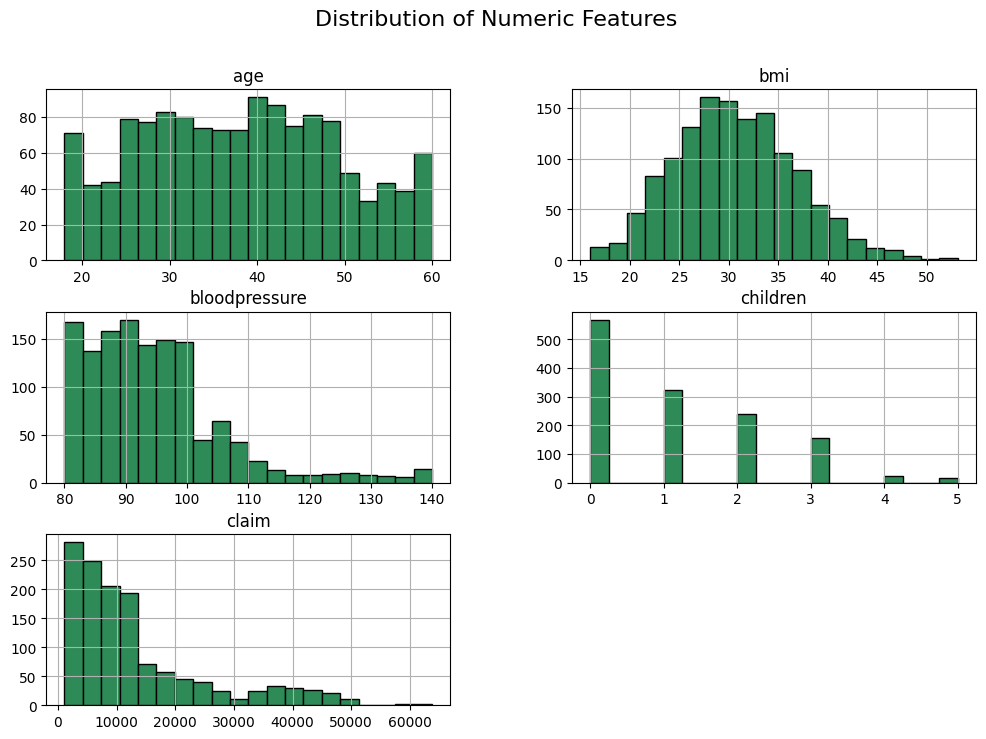

In [10]:
num_cols=['age', 'bmi', 'bloodpressure', 'children', 'claim']
df[num_cols].hist(bins=20, figsize=(12,8), color='seagreen', edgecolor='black')
plt.suptitle("Distribution of Numeric Features", fontsize=16)
plt.show()

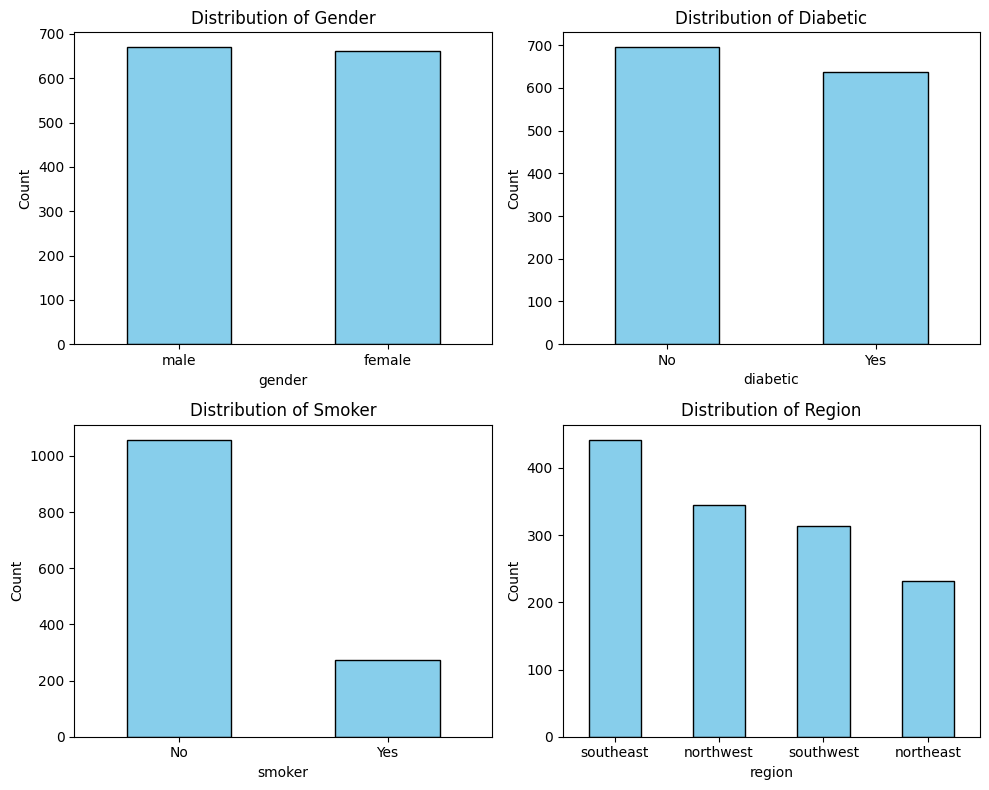

In [11]:
cat_cols=['gender', 'diabetic', 'smoker', 'region']
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 8))
axes = axes.flatten()
for i, col in enumerate(cat_cols):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col.capitalize()}')
    axes[i].set_ylabel('Count')
    axes[i].tick_params(axis='x', rotation=0) 

plt.tight_layout()
plt.show()


In [14]:
df.groupby(['gender','smoker'])['claim'].mean().round()

gender  smoker
female  No         8762.0
        Yes       30679.0
male    No         8169.0
        Yes       33042.0
Name: claim, dtype: float64